In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# No cambien el nombre del csv, cuenta duplicados
RUTA = "toneladas_carga_SFM_2510.csv"
df = pd.read_csv(RUTA)

print("Filas, columnas:", df.shape)
df.head()

Filas, columnas: (384994, 7)


,per_anual,per_mes,grupo,subgrupo,producto,ton_netas,fecha
0,2014,Enero,Agrícolas,Forrajes,Cáscara de soya,1915.142,2014-01-01
1,2014,Enero,Agrícolas,Forrajes,Cáscara de soya,308.250,2014-01-01
2,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,33582.135,2014-01-01
3,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,81.950,2014-01-01
4,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,784.601,2014-01-01


In [2]:
display(df.info())

print("\nColumnas:")
print(list(df.columns))

df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384994 entries, 0 to 384993
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   per_anual  384994 non-null  int64  
 1   per_mes    384994 non-null  object 
 2   grupo      384994 non-null  object 
 3   subgrupo   384994 non-null  object 
 4   producto   384994 non-null  object 
 5   ton_netas  384841 non-null  float64
 6   fecha      384994 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 20.6+ MB


None


Columnas:
['per_anual', 'per_mes', 'grupo', 'subgrupo', 'producto', 'ton_netas', 'fecha']


per_anual      int64
per_mes       object
grupo         object
subgrupo      object
producto      object
ton_netas    float64
fecha         object
dtype: object

In [3]:
df2 = df.copy()

# De otra forma cree que es cadena
df2['fecha'] = pd.to_datetime(df2['fecha'], errors='coerce')

df2['ton_netas'] = pd.to_numeric(df2['ton_netas'], errors='coerce')

# nulos
print("Nulos en fecha:", df2['fecha'].isna().sum())
print("Nulos en ton_netas:", df2['ton_netas'].isna().sum())

df2.head()

Nulos en fecha: 0
Nulos en ton_netas: 153


,per_anual,per_mes,grupo,subgrupo,producto,ton_netas,fecha
0,2014,Enero,Agrícolas,Forrajes,Cáscara de soya,1915.142,2014-01-01
1,2014,Enero,Agrícolas,Forrajes,Cáscara de soya,308.250,2014-01-01
2,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,33582.135,2014-01-01
3,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,81.950,2014-01-01
4,2014,Enero,Agrícolas,Forrajes,Forrajes pastas y semillas oleaginosas,784.601,2014-01-01


In [4]:
nulos = df2.isna().sum().sort_values(ascending=True)

print("Nulos por columna:")
display(nulos)

dup = df2.duplicated().sum()
print("\nFilas duplicadas exactas:", dup)

Nulos por columna:


per_anual      0
per_mes        0
grupo          0
subgrupo       0
producto       0
fecha          0
ton_netas    153
dtype: int64


Filas duplicadas exactas: 32577


In [5]:
fmin, fmax = df2['fecha'].min(), df2['fecha'].max()
print("Rango de fechas:", fmin, "→", fmax)

# año
df2['año'] = df2['fecha'].dt.year
conteo_anual = df2.groupby('año').size().sort_index()

print("\nNúmero de años en el dataset:", conteo_anual.shape[0])
print("Registros por año:")

display(conteo_anual)

Rango de fechas: 2014-01-01 00:00:00 → 2025-10-01 00:00:00

Número de años en el dataset: 12
Registros por año:


año
2014      8874
2015      8663
2016      8337
2017      8991
2018     25854
2019     20259
2020     16529
2021     21458
2022     24190
2023     23057
2024    118306
2025    100476
dtype: int64

In [6]:
df2['ton_netas'].describe()

count    384841.000000
mean       3862.316212
std       18535.167304
min       -1704.560000
25%          85.479000
50%         217.199000
75%        1286.640000
max      693085.244000
Name: ton_netas, dtype: float64

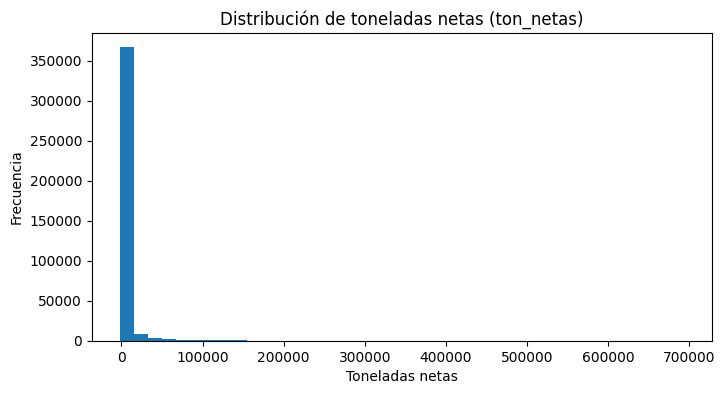

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df2['ton_netas'], bins=40)
plt.title("Distribución de toneladas netas (ton_netas)")
plt.xlabel("Toneladas netas")
plt.ylabel("Frecuencia")
plt.show()

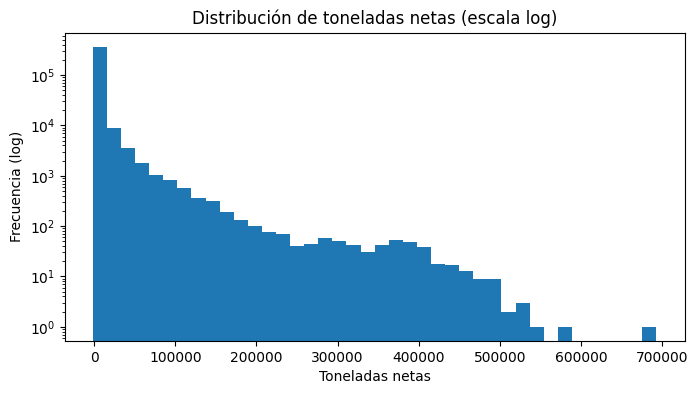

In [8]:
plt.figure(figsize=(8,4))
plt.hist(df2['ton_netas'], bins=40, log=True)
plt.title("Distribución de toneladas netas (escala log)")
plt.xlabel("Toneladas netas")
plt.ylabel("Frecuencia (log)")
plt.show()

In [9]:
dfp = df2.copy()

print("Dimensiones:", dfp.shape)
print("Nulos ton_netas:", dfp['ton_netas'].isna().sum())
print("Negativos ton_netas:", (dfp['ton_netas'] < 0).sum())
print("Duplicados exactos:", dfp.duplicated().sum())

Dimensiones: (384994, 8)
Nulos ton_netas: 153
Negativos ton_netas: 8
Duplicados exactos: 32577


In [10]:
list(df2.columns)

['per_anual',
 'per_mes',
 'grupo',
 'subgrupo',
 'producto',
 'ton_netas',
 'fecha',
 'año']

In [11]:
antes = dfp.shape[0]
dfp = dfp.drop_duplicates()
despues = dfp.shape[0]

print("Filas eliminadas por duplicado exacto:", antes - despues)
print("Datos después de limpieza:", dfp.shape)
print("Nulos ton_netas:", dfp['ton_netas'].isna().sum())
print("Negativos ton_netas:", (dfp['ton_netas'] < 0).sum())

Filas eliminadas por duplicado exacto: 32577
Datos después de limpieza: (352417, 8)
Nulos ton_netas: 137
Negativos ton_netas: 8


In [12]:
antes = dfp.shape[0]
dfp = dfp[dfp['ton_netas'].isna() | (dfp['ton_netas'] >= 0)].copy()
despues = dfp.shape[0]

print("Filas eliminadas por ton_netas negativa:", antes - despues)
print("Negativos restantes:", (dfp['ton_netas'] < 0).sum())

Filas eliminadas por ton_netas negativa: 8
Negativos restantes: 0


In [13]:
import pandas as pd
import numpy as np

df_imp = dfp.copy()

# ya no vi si se convirtieron
df_imp['fecha'] = pd.to_datetime(df_imp['fecha'], errors='coerce')
df_imp['ton_netas'] = pd.to_numeric(df_imp['ton_netas'], errors='coerce')

df_imp = df_imp.drop_duplicates()

df_imp = df_imp[df_imp['ton_netas'].isna() | (df_imp['ton_netas'] >= 0)].copy()

ts_m = (
    df_imp.dropna(subset=['fecha'])
          .set_index('fecha')['ton_netas']
          .resample('MS')
          .sum(min_count=1)   
          .sort_index()
)

print("Rango fechas:", ts_m.index.min(), "→", ts_m.index.max())
print("Meses en serie (observados):", ts_m.shape[0])
print("Meses con NaN (antes):", int(ts_m.isna().sum()))

idx = pd.date_range(ts_m.index.min(), ts_m.index.max(), freq='MS')
ts_m = ts_m.reindex(idx)

print("Meses en serie (continuo):", ts_m.shape[0])
print("Meses con NaN (continuo, antes):", int(ts_m.isna().sum()))

ts_m_imp = ts_m.interpolate(method='time')
ts_m_imp = ts_m_imp.ffill().bfill()

print("Meses con NaN (después):", int(ts_m_imp.isna().sum()))

ts_m_imp.head(12)

Rango fechas: 2014-01-01 00:00:00 → 2025-10-01 00:00:00
Meses en serie (observados): 142
Meses con NaN (antes): 0
Meses en serie (continuo): 142
Meses con NaN (continuo, antes): 0
Meses con NaN (después): 0


2014-01-01    9.285741e+06
2014-02-01    8.566469e+06
2014-03-01    9.788594e+06
2014-04-01    9.694448e+06
2014-05-01    1.020123e+07
2014-06-01    9.790476e+06
2014-07-01    1.027698e+07
2014-08-01    9.909119e+06
2014-09-01    9.434184e+06
2014-10-01    9.721202e+06
2014-11-01    9.321755e+06
2014-12-01    9.506122e+06
Freq: MS, Name: ton_netas, dtype: float64

In [14]:
mes_map = {
    "Enero": 1,
    "Febrero": 2,
    "Marzo": 3,
    "Abril": 4,
    "Mayo": 5,
    "Junio": 6,
    "Julio": 7,
    "Agosto": 8,
    "Septiembre": 9,
    "Octubre": 10,
    "Noviembre": 11,
    "Diciembre": 12
}

dfp["mes_num"] = dfp["per_mes"].map(mes_map)

dfp["anio_mes"] = pd.to_datetime(
    dict(
        year=dfp["per_anual"],
        month=dfp["mes_num"],
        day=1
    )
)

In [15]:
print("Nulos ANTES en ton_netas:", dfp['ton_netas'].isna().sum())

# Mediana mensual
mediana_mensual = dfp.groupby('anio_mes')['ton_netas'].transform('median')

# Imputación
dfp['ton_netas'] = dfp['ton_netas'].fillna(mediana_mensual)

# Nulos después
print("Nulos DESPUÉS en ton_netas:", dfp['ton_netas'].isna().sum())

Nulos ANTES en ton_netas: 137
Nulos DESPUÉS en ton_netas: 0


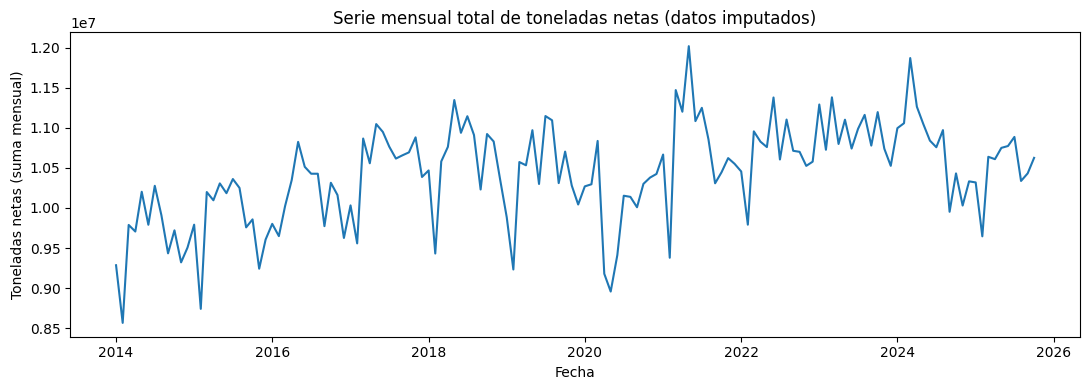

In [16]:
ts_m = (
    dfp.set_index('fecha')['ton_netas']
       .resample('MS')
       .sum()
       .sort_index()
)

plt.figure(figsize=(11,4))
plt.plot(ts_m.index, ts_m.values)

plt.title("Serie mensual total de toneladas netas (datos imputados)")
plt.xlabel("Fecha")
plt.ylabel("Toneladas netas (suma mensual)")

plt.tight_layout()
plt.show()

### Medias móviles y aparición de valores NaN

Los valores **NaN** que aparecen al inicio de las columnas `ma_3`, `ma_6` y `ma_12` se deben al funcionamiento de las **ventanas móviles (`rolling`)**.

Una media móvil necesita un número mínimo de observaciones para poder calcularse:

- `ma_3` necesita **3 meses** de datos
- `ma_6` necesita **6 meses** de datos
- `ma_12` necesita **12 meses** de datos

Por esta razón, en los primeros registros del dataset no existe suficiente información histórica para calcular la media, por lo que **Pandas asigna NaN automáticamente** hasta que se completa el tamaño de la ventana.

Este comportamiento es esperado y forma parte del cálculo normal de las medias móviles en series de tiempo.

In [17]:

df_ma = ts_m.to_frame(name='ton_netas')

df_ma['ma_3'] = df_ma['ton_netas'].rolling(3).mean()
df_ma['ma_6'] = df_ma['ton_netas'].rolling(6).mean()
df_ma['ma_12'] = df_ma['ton_netas'].rolling(12).mean()

df_ma.head(15)

,ton_netas,ma_3,ma_6,ma_12
fecha,,,,
2014-01-01,9.285741e+06,NaN,NaN,NaN
2014-02-01,8.566469e+06,NaN,NaN,NaN
2014-03-01,9.788594e+06,9.213601e+06,NaN,NaN
2014-04-01,9.706411e+06,9.353825e+06,NaN,NaN
2014-05-01,1.020269e+07,9.899232e+06,NaN,NaN
2014-06-01,9.790476e+06,9.899860e+06,9.556731e+06,NaN
2014-07-01,1.027698e+07,1.009005e+07,9.721936e+06,NaN
2014-08-01,9.909119e+06,9.992191e+06,9.945711e+06,NaN
2014-09-01,9.434184e+06,9.873427e+06,9.886643e+06,NaN


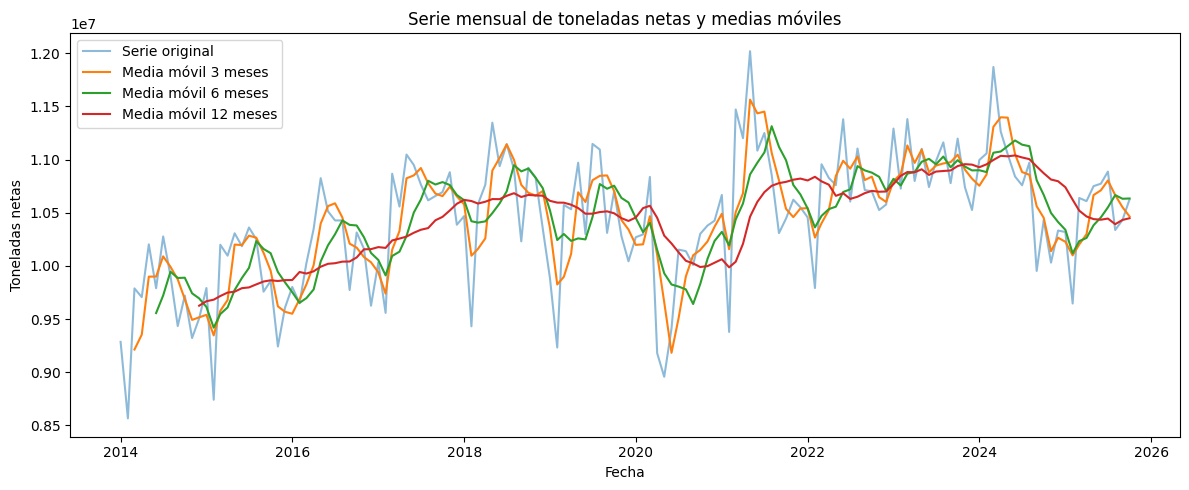

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df_ma.index, df_ma['ton_netas'], label='Serie original', alpha=0.5)
plt.plot(df_ma.index, df_ma['ma_3'], label='Media móvil 3 meses')
plt.plot(df_ma.index, df_ma['ma_6'], label='Media móvil 6 meses')
plt.plot(df_ma.index, df_ma['ma_12'], label='Media móvil 12 meses')

plt.title("Serie mensual de toneladas netas y medias móviles")
plt.xlabel("Fecha")
plt.ylabel("Toneladas netas")

plt.legend()
plt.tight_layout()
plt.show()# se acorta al inicio por el calculo de la media movil

In [19]:

df_features = ts_m.to_frame(name='ton_netas')

# demanda del mismo mes del año anterior
df_features['lag_12'] = df_features['ton_netas'].shift(12)

# crecimiento anual de la demanda
df_features['crecimiento_anual'] = (
    (df_features['ton_netas'] - df_features['lag_12']) / df_features['lag_12']
)

df_features.head()

,ton_netas,lag_12,crecimiento_anual
fecha,,,
2014-01-01,9.285741e+06,NaN,NaN
2014-02-01,8.566469e+06,NaN,NaN
2014-03-01,9.788594e+06,NaN,NaN
2014-04-01,9.706411e+06,NaN,NaN
2014-05-01,1.020269e+07,NaN,NaN


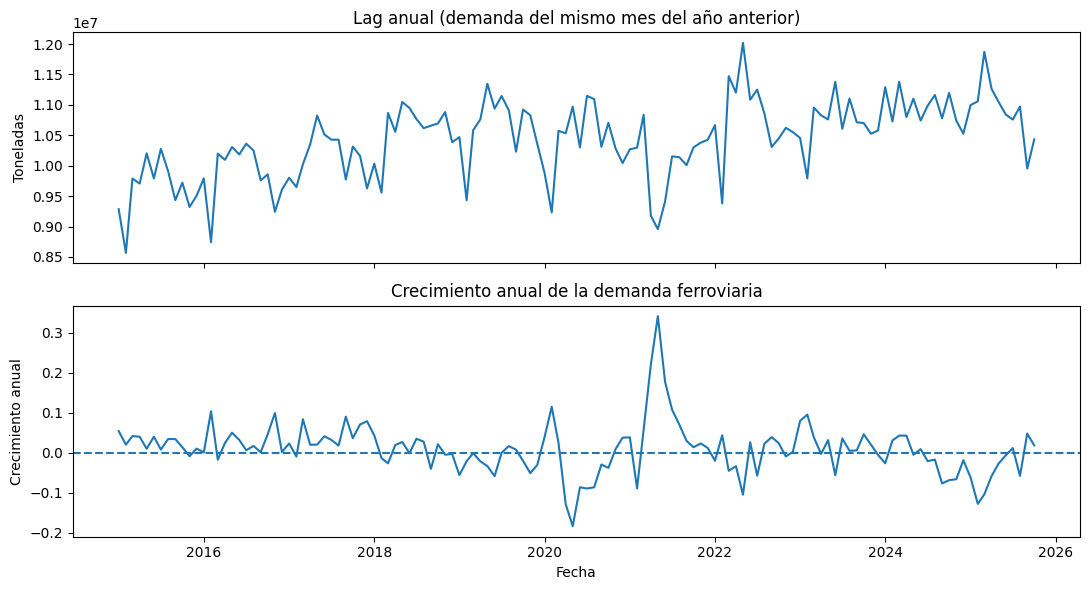

In [20]:
fig, ax = plt.subplots(2, 1, figsize=(11,6), sharex=True)

ax[0].plot(df_features.index, df_features['lag_12'])
ax[0].set_title("Lag anual (demanda del mismo mes del año anterior)")
ax[0].set_ylabel("Toneladas")

ax[1].plot(df_features.index, df_features['crecimiento_anual'])
ax[1].axhline(0, linestyle='--')
ax[1].set_title("Crecimiento anual de la demanda ferroviaria")
ax[1].set_ylabel("Crecimiento anual")
ax[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

Antes


,ton_netas,lag_12,crecimiento_anual
count,1.420000e+02,1.300000e+02,130.000000
mean,1.042557e+07,1.042346e+07,0.009540
std,6.105847e+05,6.301039e+05,0.062971
min,8.566469e+06,8.566469e+06,-0.183506
25%,1.005681e+07,1.003539e+07,-0.020618
50%,1.049116e+07,1.049116e+07,0.012044
75%,1.083500e+07,1.085241e+07,0.037669
max,1.201917e+07,1.201917e+07,0.341813


Después


,ton_netas,lag_12,crecimiento_anual
count,1.420000e+02,1.300000e+02,1.300000e+02
mean,1.901452e-15,-1.011157e-15,4.099285e-17
std,1.003540e+00,1.003868e+00,1.003868e+00
min,-3.055572e+00,-2.958511e+00,-3.077474e+00
25%,-6.060856e-01,-6.182639e-01,-4.807677e-01
50%,1.077959e-01,1.078664e-01,3.991358e-02
75%,6.729192e-01,6.833955e-01,4.484214e-01
max,2.619194e+00,2.542264e+00,5.296987e+00


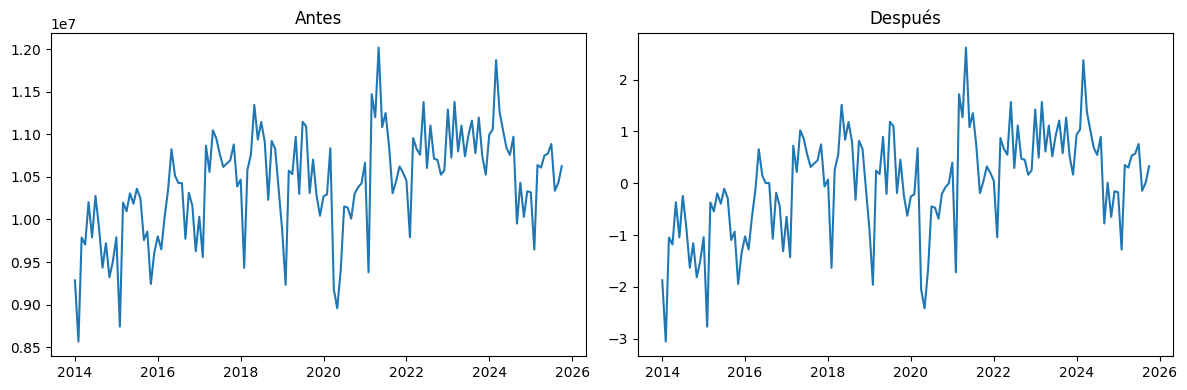

In [21]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

cols = ['ton_netas', 'lag_12', 'crecimiento_anual']

# antes del escalado
print("Antes")
display(df_features[cols].describe())

# después del escalado
scaler = StandardScaler()
df_scaled = df_features.copy()
df_scaled[cols] = scaler.fit_transform(df_scaled[cols])

print("Después")
display(df_scaled[cols].describe())

# visualización 
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(df_features.index, df_features['ton_netas'])
ax[0].set_title("Antes")

ax[1].plot(df_scaled.index, df_scaled['ton_netas'])
ax[1].set_title("Después")

plt.tight_layout()
plt.show()

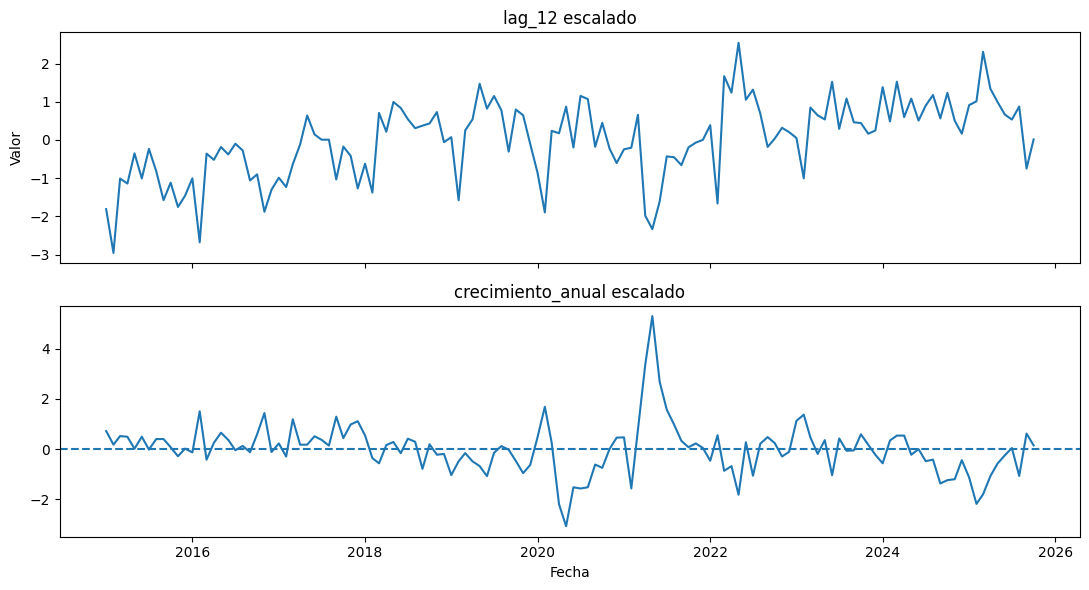

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(11,6), sharex=True)

ax[0].plot(df_scaled.index, df_scaled['lag_12'])
ax[0].set_title("lag_12 escalado")
ax[0].set_ylabel("Valor")

ax[1].plot(df_scaled.index, df_scaled['crecimiento_anual'])
ax[1].axhline(0, linestyle='--')
ax[1].set_title("crecimiento_anual escalado")
ax[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

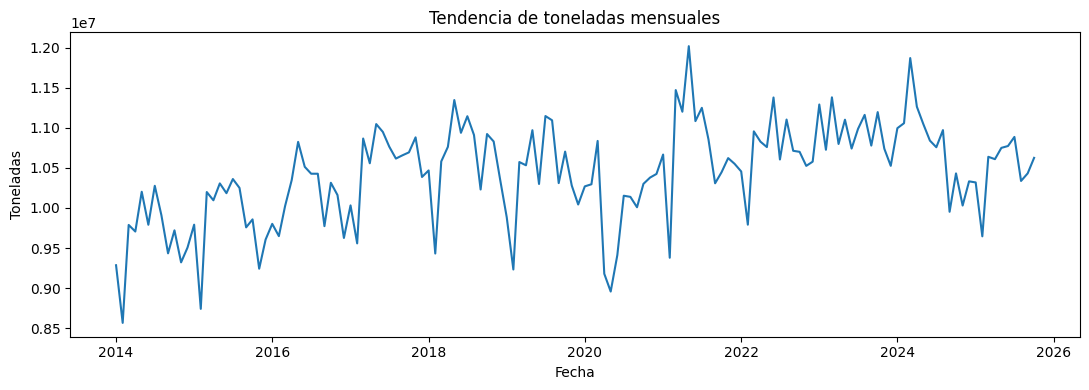

In [23]:
plt.figure(figsize=(11,4))

plt.plot(ts_m.index, ts_m.values)

plt.title("Tendencia de toneladas mensuales")
plt.xlabel("Fecha")
plt.ylabel("Toneladas")

plt.tight_layout()
plt.show()

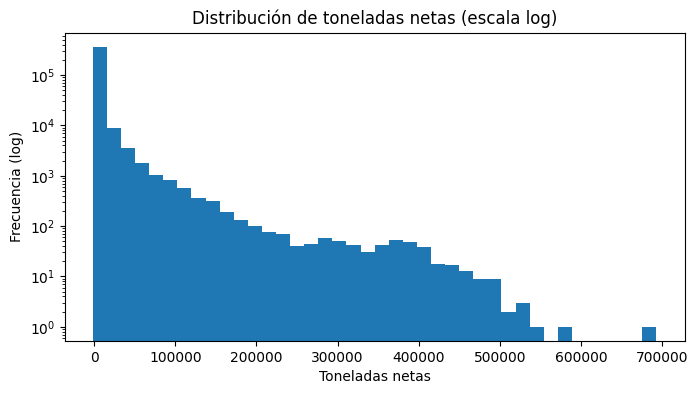

In [24]:
# de nuevo a escala log porque no se aprecia bien la distribución
plt.figure(figsize=(8,4))
plt.hist(df2['ton_netas'], bins=40, log=True)
plt.title("Distribución de toneladas netas (escala log)")
plt.xlabel("Toneladas netas")
plt.ylabel("Frecuencia (log)")
plt.show()

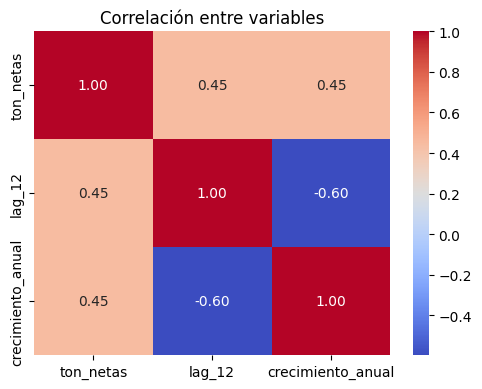

In [25]:
import seaborn as sns

corr = df_features[['ton_netas','lag_12','crecimiento_anual']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlación entre variables")

plt.tight_layout()
plt.show()

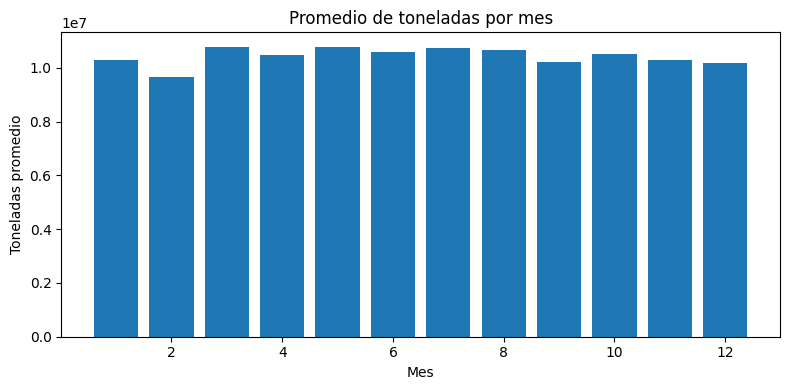

In [26]:
df_mes = ts_m.to_frame(name='ton_netas')
df_mes['mes'] = df_mes.index.month

prom_mes = df_mes.groupby('mes')['ton_netas'].mean()

plt.figure(figsize=(8,4))
plt.bar(prom_mes.index, prom_mes.values)

plt.title("Promedio de toneladas por mes")
plt.xlabel("Mes")
plt.ylabel("Toneladas promedio")

plt.tight_layout()
plt.show()

In [27]:

import plotly.express as px # lo cabie a potly para que puedan verse mejor los datos, y se vean mejores las graficas

df_season = ts_m.to_frame(name='ton_netas')

df_season['anio'] = df_season.index.year
df_season['mes'] = df_season.index.month

fig = px.line(
    df_season,
    x='mes',
    y='ton_netas',
    color='anio',
    markers=True,
    title="Estacionalidad mensual por año",
    labels={'mes':'Mes','ton_netas':'Toneladas','anio':'Año'}
)

fig.show()

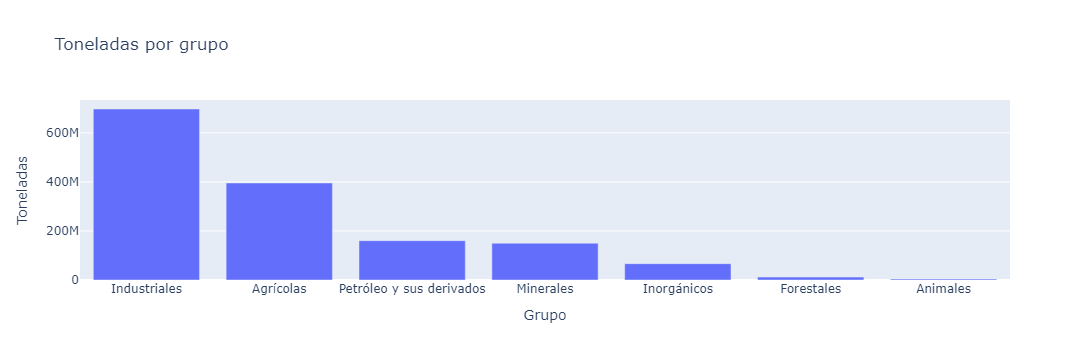

In [28]:
import plotly.express as px

top_grupos = (
    df2.groupby('grupo')['ton_netas']
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .reset_index()
)

fig = px.bar(
    top_grupos,
    x='grupo',
    y='ton_netas',
    title="Toneladas por grupo",
    labels={'grupo': 'Grupo', 'ton_netas': 'Toneladas'}
)

fig.show()

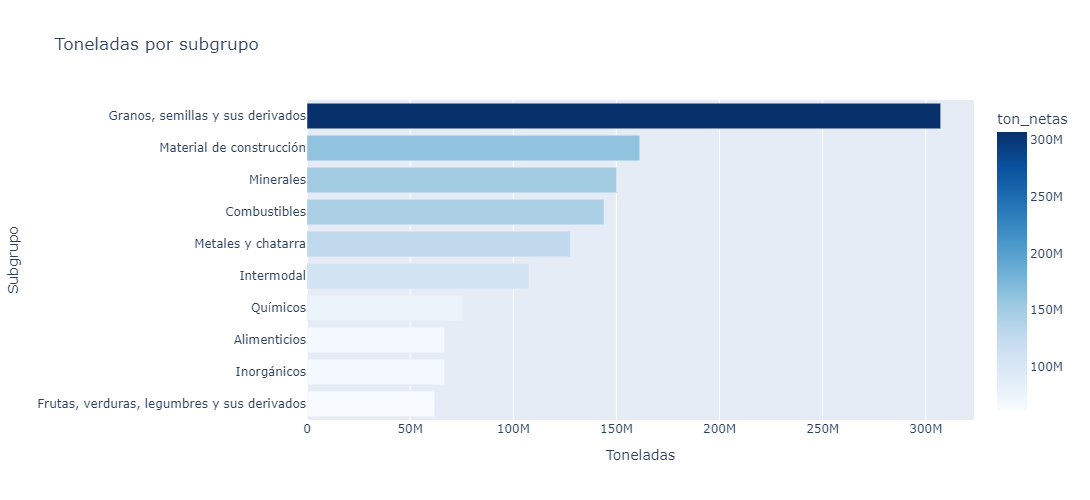

In [29]:
import plotly.express as px
#las ouse por subgrupos, para ver otro enfoque y sea mas exacto su distribucion
top_sub = (
    df2.groupby('subgrupo')['ton_netas']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig = px.bar(
    top_sub,
    x='ton_netas',
    y='subgrupo',
    orientation='h',
    color='ton_netas',
    color_continuous_scale='Blues',
    title="Toneladas por subgrupo"
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    xaxis_title="Toneladas",
    yaxis_title="Subgrupo",
    height=500
)

fig.show()

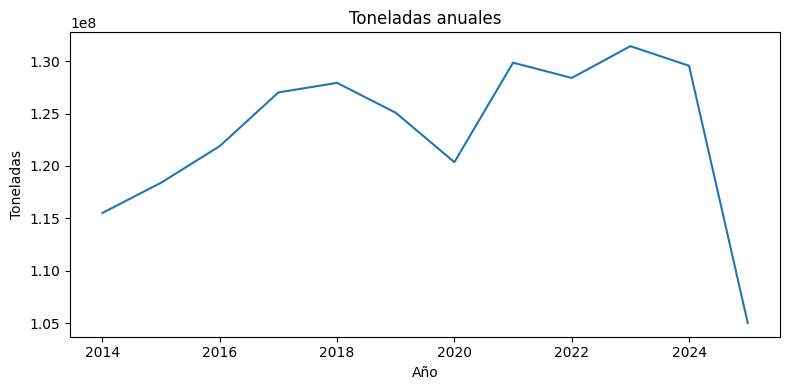

In [30]:
df_anual = ts_m.resample('YE').sum() # debemos modificar para que no salga la advertencia

plt.figure(figsize=(8,4))

plt.plot(df_anual.index.year, df_anual.values)

plt.title("Toneladas anuales")
plt.xlabel("Año")
plt.ylabel("Toneladas")

plt.tight_layout()
plt.show()

Cambios estructurales detectados: 1
Fechas de los cambios:
 → 2017-02


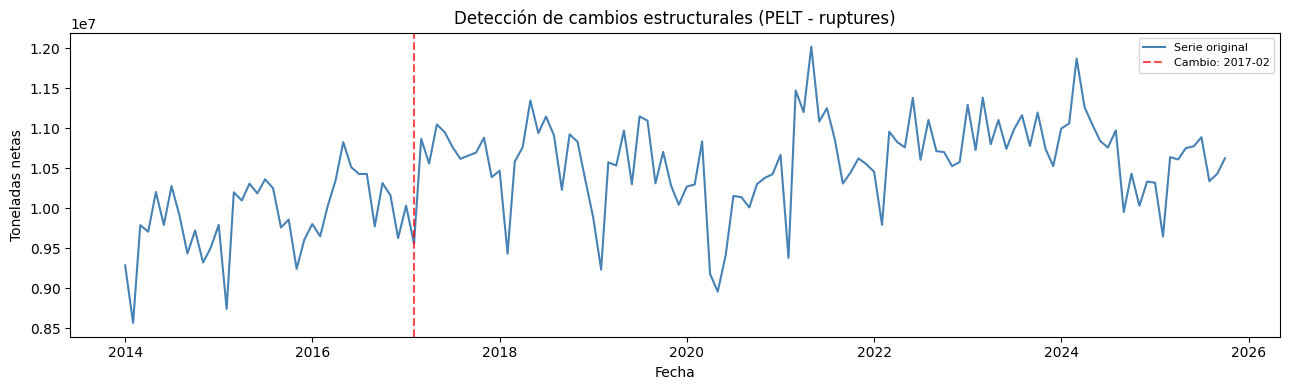

In [32]:
import ruptures as rpt
import matplotlib.pyplot as plt
import numpy as np

# Serie mensual agregada (viene de tu código anterior)
# ts_m ya debe estar definida como serie con índice de fechas

y = ts_m.values
n = len(y)

# Algoritmo PELT con modelo rbf — detecta cambios en media y varianza
modelo_rpt = rpt.Pelt(model="rbf", min_size=3, jump=1).fit(y)
breakpoints = modelo_rpt.predict(pen=10)  # pen controla sensibilidad

# Convertir índices a fechas
fechas_bp = ts_m.index[np.array(breakpoints[:-1]) - 1]

print(f"Cambios estructurales detectados: {len(breakpoints) - 1}")
print("Fechas de los cambios:")
for f in fechas_bp:
    print(" →", f.strftime("%Y-%m"))

# Visualización
plt.figure(figsize=(13, 4))
plt.plot(ts_m.index, ts_m.values, label="Serie original", color="steelblue")

for f in fechas_bp:
    plt.axvline(f, color="red", linestyle="--", alpha=0.7, label=f"Cambio: {f.strftime('%Y-%m')}")

plt.title("Detección de cambios estructurales (PELT - ruptures)")
plt.xlabel("Fecha")
plt.ylabel("Toneladas netas")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [70]:
import pandas as pd
import numpy as np
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')

def build_features(ts):
    d = pd.DataFrame({'y': ts})
    d['mes']        = d.index.month
    d['anio']       = d.index.year
    d['mes_sin']    = np.sin(2 * np.pi * d['mes'] / 12)
    d['mes_cos']    = np.cos(2 * np.pi * d['mes'] / 12)
    d['trimestre']  = d.index.quarter
    d['tendencia']  = np.arange(len(d))
    d['covid']      = ((d.index >= '2020-03-01') & (d.index < '2021-01-01')).astype(int)
    d['post_covid'] = (d.index >= '2021-01-01').astype(int)
    for lag in [1, 2, 3, 6, 12, 24]:
        d[f'lag_{lag}'] = d['y'].shift(lag)
    for w in [3, 6, 12]:
        d[f'ma_{w}']  = d['y'].shift(1).rolling(w).mean()
        d[f'std_{w}'] = d['y'].shift(1).rolling(w).std()
    d['crec_anual'] = (d['y'] - d['lag_12']) / d['lag_12']
    d['crec_mes']   = (d['y'] - d['lag_1'])  / d['lag_1']
    return d.dropna()

# Serie mensual (viene de dfp)
ts_m = (
    dfp.set_index('fecha')['ton_netas']
       .resample('MS').sum()
       .sort_index()
)

data      = build_features(ts_m)
HORIZONTE = 12
train     = data.iloc[:-HORIZONTE]
test      = data.iloc[-HORIZONTE:]
features  = [c for c in data.columns if c != 'y']

X_train, y_train = train[features], train['y']
X_test,  y_test  = test[features],  test['y']

# Entrenar XGBoost 
modelo_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
modelo_xgb.fit(X_train, y_train)

# Predicción y métricas
y_pred = modelo_xgb.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mape = (np.abs((y_test - y_pred) / y_test) * 100).mean()

print("MÉTRICAS DE EVALUACIÓN — XGBoost")
print("MAE: ", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:  ", round(r2, 4))
print("MAPE:", round(mape, 4))

MÉTRICAS DE EVALUACIÓN — XGBoost
MAE:  84021.15
RMSE: 101197.99
R²:   0.9085
MAPE: 0.8101


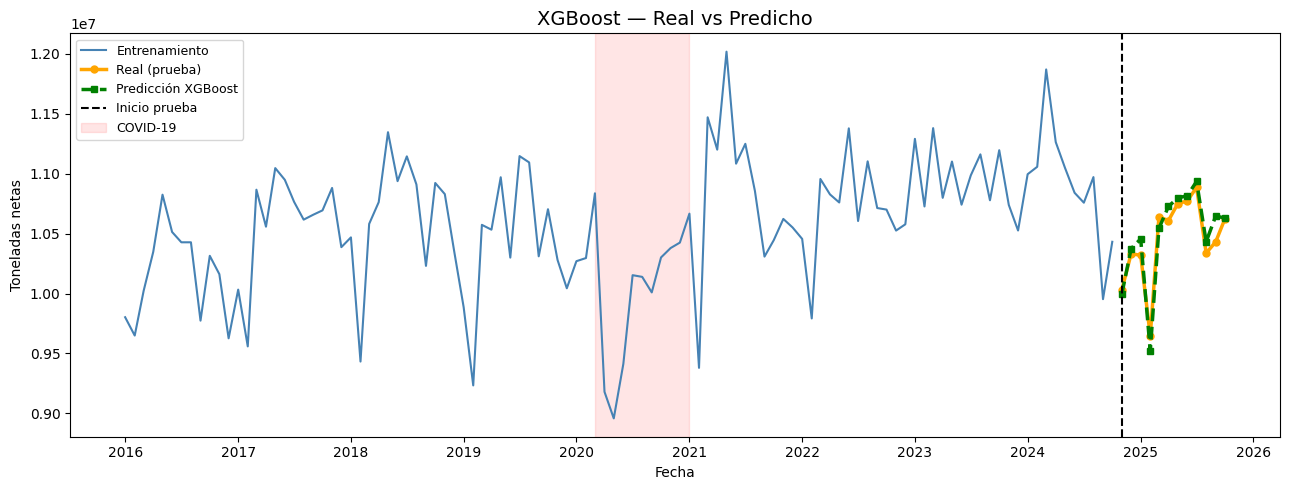

In [71]:
import matplotlib.pyplot as plt

fechas_test = test.index

plt.figure(figsize=(13, 5))

plt.plot(train.index, train['y'], color='steelblue', label='Entrenamiento')
plt.plot(fechas_test, y_test.values, color='orange', linewidth=2.5,
         marker='o', markersize=5, label='Real (prueba)')
plt.plot(fechas_test, y_pred, color='green', linewidth=2.5,
         linestyle='--', marker='s', markersize=5, label='Predicción XGBoost')

plt.axvline(fechas_test[0], color='black', linestyle='--',
            linewidth=1.5, label='Inicio prueba')
plt.axvspan('2020-03-01', '2021-01-01', alpha=0.1, color='red', label='COVID-19')

plt.title("XGBoost — Real vs Predicho", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Toneladas netas")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

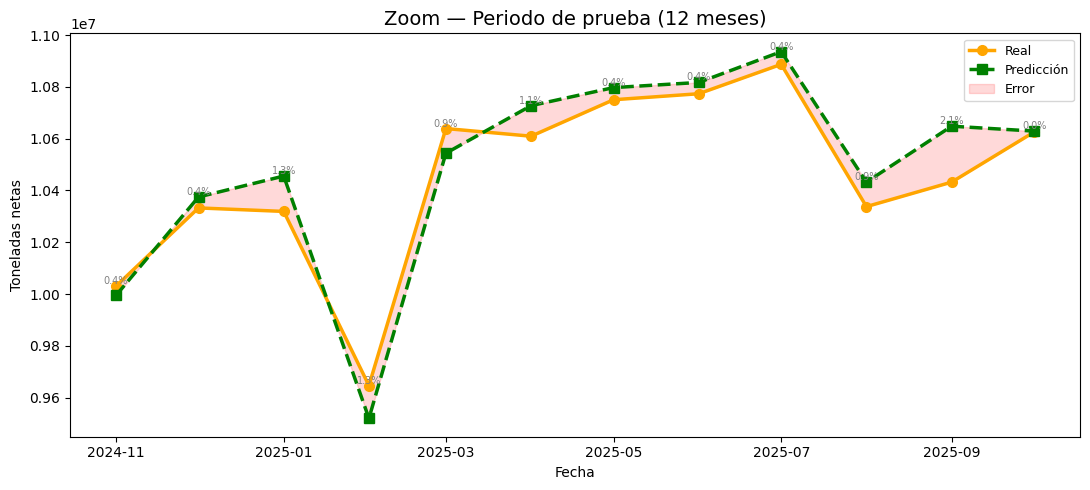

In [72]:
plt.figure(figsize=(11, 5))

plt.plot(fechas_test, y_test.values, color='orange', linewidth=2.5,
         marker='o', markersize=7, label='Real')
plt.plot(fechas_test, y_pred, color='green', linewidth=2.5,
         linestyle='--', marker='s', markersize=7, label='Predicción')

for f, real, pred in zip(fechas_test, y_test.values, y_pred):
    error_pct = abs(real - pred) / real * 100
    plt.annotate(f'{error_pct:.1f}%', xy=(f, max(real, pred)),
                 fontsize=7, ha='center', va='bottom', color='gray')

plt.fill_between(fechas_test, y_test.values, y_pred,
                 alpha=0.15, color='red', label='Error')

plt.title("Zoom — Periodo de prueba (12 meses)", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Toneladas netas")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

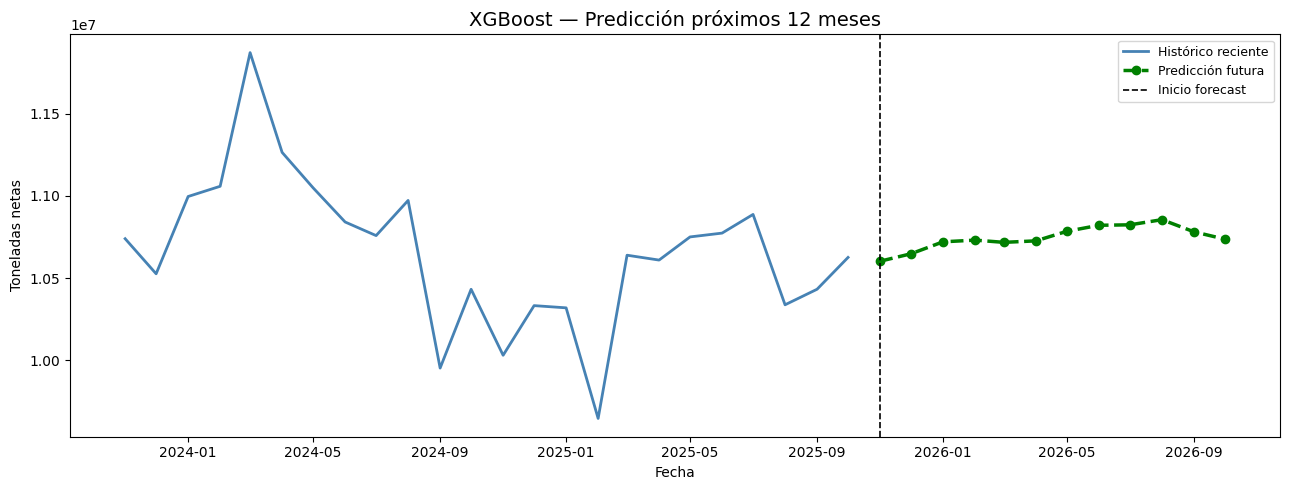


Predicción próximos 12 meses:


,Fecha,Predicción
0,2025-11,"10,602,354"
1,2025-12,"10,647,846"
2,2026-01,"10,720,406"
3,2026-02,"10,730,652"
4,2026-03,"10,717,114"
5,2026-04,"10,726,273"
6,2026-05,"10,784,546"
7,2026-06,"10,820,924"
8,2026-07,"10,823,729"
9,2026-08,"10,855,075"


In [73]:
from xgboost import XGBRegressor

modelo_futuro = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
modelo_futuro.fit(data[features], data['y'])

# Predecir mes a mes
ts_ext = ts_m.copy()
fechas_futuras = pd.date_range(
    start=ts_m.index[-1] + pd.DateOffset(months=1),
    periods=12, freq='MS'
)

pred_futuros = []
for fecha in fechas_futuras:
    fila = {}
    fila['mes']        = fecha.month
    fila['anio']       = fecha.year
    fila['mes_sin']    = np.sin(2 * np.pi * fecha.month / 12)
    fila['mes_cos']    = np.cos(2 * np.pi * fecha.month / 12)
    fila['trimestre']  = fecha.quarter
    fila['tendencia']  = len(ts_ext)
    fila['covid']      = 0
    fila['post_covid'] = 1
    for lag in [1, 2, 3, 6, 12, 24]:
        idx = len(ts_ext) - lag
        fila[f'lag_{lag}'] = ts_ext.iloc[idx] if idx >= 0 else np.nan
    for w in [3, 6, 12]:
        fila[f'ma_{w}']  = ts_ext.iloc[-w:].mean()
        fila[f'std_{w}'] = ts_ext.iloc[-w:].std()
    lag1  = ts_ext.iloc[-1]
    lag12 = ts_ext.iloc[-12] if len(ts_ext) >= 12 else np.nan
    fila['crec_anual'] = (lag1 - lag12) / lag12 if lag12 else 0
    fila['crec_mes']   = 0

    X_fut    = pd.DataFrame([fila])[features]
    pred_val = modelo_futuro.predict(X_fut)[0]
    pred_futuros.append(pred_val)
    ts_ext = pd.concat([ts_ext, pd.Series([pred_val], index=[fecha])])

# Gráfica
plt.figure(figsize=(13, 5))
plt.plot(ts_m.index[-24:], ts_m.values[-24:],
         color='steelblue', linewidth=2, label='Histórico reciente')
plt.plot(fechas_futuras, pred_futuros,
         color='green', linewidth=2.5, linestyle='--',
         marker='o', markersize=6, label='Predicción futura')
plt.axvline(fechas_futuras[0], color='black', linestyle='--',
            linewidth=1.2, label='Inicio forecast')

plt.title("XGBoost — Predicción próximos 12 meses", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Toneladas netas")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

tabla_futuro = pd.DataFrame({
    'Fecha':      fechas_futuras.strftime('%Y-%m'),
    'Predicción': [f"{v:,.0f}" for v in pred_futuros]
})
print("\nPredicción próximos 12 meses:")
display(tabla_futuro)